Integrantes:

ALINE DE ALBUQUERQUE OSHIRO SATO

ALEXIS DANIEL MENESES CANEZ


# AULA 7: MODELOS VEC

ATIVIDADE EM GRUPO
Considerando as séries diárias dos preços ajustados das ações da BHP e VALE, entre 2002 e 2006, realize as atividades descritas a seguir.

Para acessar as séries de preços e realizar os respectivos tratamentos iniciais, utilize o seguinte diretório no GitHub:

In [2]:
install.packages("timetk")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘TTR’, ‘prodlim’, ‘globals’, ‘quadprog’, ‘quantmod’, ‘listenv’, ‘parallelly’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘furrr’, ‘lazyeval’, ‘crosstalk’, ‘warp’, ‘BH’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘tseries’, ‘urca’, ‘RcppArmadillo’, ‘RcppRoll’, ‘future’, ‘recipes’, ‘rsample’, ‘plotly’, ‘padr’, ‘xts’, ‘zoo’, ‘slider’, ‘anytime’, ‘timeDate’, ‘forecast’, ‘tsfeatures’




In [3]:
install.packages("vars")
install.packages("urca")
install.packages("stats")
install.packages("forecast")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘strucchange’, ‘sandwich’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘stats’ is a base package, and should not be updated”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [18]:
# Carregamento de bibliotecas necessárias
library(tidyverse)  # Conjunto de pacotes para manipulação de dados e visualização
library(timetk)     # Ferramentas para manipulação de séries temporais
library(vars)       # Modelagem de vetores autoregressivos e VECM
library(urca)       # Testes de raízes unitárias e cointegração
library(stats)      # Funções estatísticas básicas
library(forecast)   # Ferramentas para previsão de séries temporais
library(tseries)
theme_set(theme_bw())  # Configura o tema padrão para gráficos

Rows: 946 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: " "
dbl (9): Mon, day, year, open, high, low, close, volume, adjclose

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 946 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: " "
dbl (9): Mon, day, year, open, high, low, close, volume, adjclose

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


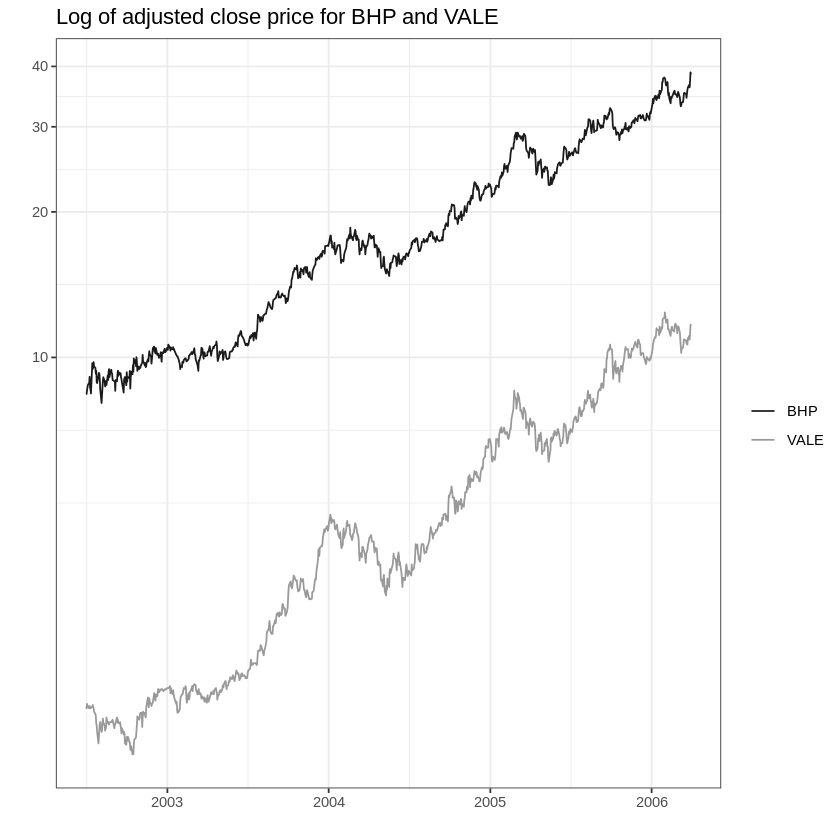

In [17]:
# URL para os dados de preços ajustados das ações BHP e VALE
webpage = "https://faculty.chicagobooth.edu/-/media/faculty/ruey-s-tsay/teaching/fts3/"

# Leitura e preparação dos dados
y_tbl <-
  inner_join(read_delim(file = str_c(webpage, "d-bhp0206.txt"), delim = " "),
             read_delim(file = str_c(webpage, "d-vale0206.txt"), delim = " "),
             by = c("Mon", "day", "year"), suffix = c("_BHP", "_VALE")) %>%
  gather(variable, value, -c("Mon", "day", "year")) %>%
  filter(str_sub(variable, 1, 8) == "adjclose") %>%
  mutate(date = (year*10000 + Mon*100 + day) %>% as.character() %>% as.Date("%Y%m%d" ),
         variable = str_sub(variable, 10, -1),
         logvalue = log(value))

# Conversão para o formato zoo, usado para manipulação de séries temporais
y_zoo <-
  y_tbl %>%
  dplyr::select(date, variable, logvalue) %>%
  spread(variable, logvalue) %>%
  tk_zoo(select = -date, date_var = date)

# Plotagem dos preços ajustados em log para BHP e VALE
y_tbl %>%
  ggplot(aes(x = date, y = value, col = variable)) +
  geom_line() +
  scale_y_log10(breaks = c(0,10,20,30,40)) +
  scale_color_manual(values = c("gray10","gray60")) +
  labs(x = "", y = "", col = "", title = "Log of adjusted close price for BHP and VALE")

## 1. Agora que você acessou e visualizou as séries da BHP e Vale, prossiga com as seguintes análises:

### a. Comece determinando o número ótimo de defasagens para o modelo VAR com constante através da função VARselect(), utilizando o critério de informação de Akaike (AIC).

In [5]:
# Seleção do número ótimo de defasagens (lags)
lag_select <- VARselect(y_zoo, lag.max = 10, type = "const")

lag_select

,1,2,3,4,5,6,7,8,9,10
AIC(n),-1.580900e+01,-1.582714e+01,-1.582361e+01,-1.581676e+01,-1.581895e+01,-1.581437e+01,-1.581335e+01,-1.580813e+01,-1.580144e+01,-1.579699e+01
HQ(n),-1.579717e+01,-1.580742e+01,-1.579599e+01,-1.578125e+01,-1.577556e+01,-1.576309e+01,-1.575418e+01,-1.574107e+01,-1.572649e+01,-1.571415e+01
SC(n),-1.577796e+01,-1.577541e+01,-1.575119e+01,-1.572365e+01,-1.570515e+01,-1.567988e+01,-1.565817e+01,-1.563225e+01,-1.560488e+01,-1.557974e+01
FPE(n),1.362192e-07,1.337704e-07,1.342441e-07,1.351671e-07,1.348714e-07,1.354906e-07,1.356283e-07,1.363396e-07,1.372545e-07,1.378675e-07


In [6]:
lag_escolhido <- lag_select$selection["AIC(n)"]
lag_escolhido

AIC(n) 
     2

#### O número ótimo de defasagens segundo o AIC é 2.

### b. Realize o teste de cointegração para verificar a existência de uma relação de longo prazo entre as séries de preços logaritmizados de BHP e VALE. Utilize a função ca.jo() para aplicar os testes de máximo autovalor e estatística de traço, especificando o número de defasagens identificado anteriormente. Apresente os resultados dos testes e interprete o significado da presença ou ausência de cointegração.

In [7]:
# ADF em nível
# Teste ADF em nível para BHP
adf_bhp_lvl <- ur.df(y_zoo[, "BHP"], type = "drift", selectlags = "AIC")
summary(adf_bhp_lvl)

# Teste ADF em nível para VALE
adf_vale_lvl <- ur.df(y_zoo[, "VALE"], type = "drift", selectlags = "AIC")
summary(adf_vale_lvl)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.083301 -0.011210  0.000297  0.012466  0.140793 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)   
(Intercept)  0.0032607  0.0041806   0.780   0.4356   
z.lag.1     -0.0005246  0.0014513  -0.361   0.7178   
z.diff.lag  -0.0944844  0.0324710  -2.910   0.0037 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01956 on 941 degrees of freedom
Multiple R-squared:  0.009131,	Adjusted R-squared:  0.007025 
F-statistic: 4.336 on 2 and 941 DF,  p-value: 0.01335


Value of test-statistic is: -0.3615 3.8944 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.43 -2.86 -2.57
phi1  6.43  4.59  3.78



############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.071706 -0.014363 -0.000152  0.013347  0.081611 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept)  0.002040   0.001860   1.097   0.2729  
z.lag.1     -0.000152   0.001197  -0.127   0.8990  
z.diff.lag   0.060685   0.032558   1.864   0.0626 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.0224 on 941 degrees of freedom
Multiple R-squared:  0.003682,	Adjusted R-squared:  0.001565 
F-statistic: 1.739 on 2 and 941 DF,  p-value: 0.1763


Value of test-statistic is: -0.127 3.1106 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.43 -2.86 -2.57
phi1  6.43  4.59  3.78


#### Resposta b Nivel

BHP em nível

*  Estatística tau = -0.3615
*  Valor crítico para 5% = -2.86

-0.36 NÃO é menor que -2.86
➡ Não rejeita H0 (raiz unitária)
➡ BHP em nível NÃO é estacionária


VALE em nível

*  Estatística tau = -0.127
*  Valor crítico para 5% = -2.86

-0.127 NÃO é menor que -2.86
➡ Não rejeita H0 (raiz unitária)
➡ VALE em nível NÃO é estacionária

In [24]:
# Teste ADF em primeira diferença para BHP
adf_bhp_diff <- ur.df(diff(y_zoo[, "BHP"]), type = "drift", selectlags = "AIC")
summary(adf_bhp_diff)

# Teste ADF em primeira diferença para VALE
adf_vale_diff <- ur.df(diff(y_zoo[, "VALE"]), type = "drift", selectlags = "AIC")
summary(adf_vale_diff)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.083008 -0.011289  0.000289  0.012354  0.140880 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0017836  0.0006416   2.780  0.00554 ** 
z.lag.1     -1.1150444  0.0482766 -23.097  < 2e-16 ***
z.diff.lag   0.0184815  0.0326757   0.566  0.57180    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01956 on 940 degrees of freedom
Multiple R-squared:  0.5476,	Adjusted R-squared:  0.5467 
F-statistic:   569 on 2 and 940 DF,  p-value: < 2.2e-16


Value of test-statistic is: -23.097 266.7354 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.43 -2.86 -2.57
phi1  6.43  4.59  3.78



############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.073420 -0.014104 -0.000111  0.013486  0.083205 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0019328  0.0007325   2.639  0.00846 ** 
z.lag.1     -1.0087448  0.0446005 -22.617  < 2e-16 ***
z.diff.lag   0.0740451  0.0325537   2.275  0.02316 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02234 on 940 degrees of freedom
Multiple R-squared:  0.4727,	Adjusted R-squared:  0.4715 
F-statistic: 421.3 on 2 and 940 DF,  p-value: < 2.2e-16


Value of test-statistic is: -22.6173 255.7723 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.43 -2.86 -2.57
phi1  6.43  4.59  3.78


#### Resposta b Diferença

BHP em 1ª diferença

*  Estatística tau = -23.097
*  Valor crítico para 5% = -2.86

-23.097 < -2.86
➡ Rejeita H0 fortemente
➡ BHP é estacionária em 1ª diferença

VALE em 1ª diferença

*  Estatística tau = -22.6173
*  Valor crítico para 5% = -2.86

-22.62 < -2.86
➡ Rejeita H0 fortemente
➡ VALE é estacionária em 1ª diferença

#### Conclusão geral

As duas séries:

BHP

VALE

*  Não são estacionárias em nível → possuem raiz unitária
*  Ficam estacionárias após uma diferença

Portanto:

Ambas são I(1).

In [9]:
# Rodar o Johansen (trace e eigen)
# Teste de cointegração de Johansen - estatística trace
joh_trace <- ca.jo(y_zoo,
                   type  = "trace",
                   ecdet = "const",
                   K     = lag_escolhido)

summary(joh_trace)


###################### 
# Johansen-Procedure # 
###################### 

Test type: trace statistic , without linear trend and constant in cointegration 

Eigenvalues (lambda):
[1]   4.148282e-02   8.206470e-03 -8.214608e-308

Values of teststatistic and critical values of test:

          test 10pct  5pct  1pct
r <= 1 |  7.78  7.52  9.24 12.97
r = 0  | 47.77 17.85 19.96 24.60

Eigenvectors, normalised to first column:
(These are the cointegration relations)

            BHP.l2    VALE.l2  constant
BHP.l2    1.000000  1.0000000  1.000000
VALE.l2  -0.717704 -0.7327542  2.047274
constant -1.828460 -1.5411890 -5.712629

Weights W:
(This is the loading matrix)

            BHP.l2     VALE.l2      constant
BHP.d  -0.06731196 0.004568985 -1.938122e-17
VALE.d  0.02545606 0.007541565  9.876883e-18


In [10]:
# Teste de cointegração de Johansen - estatística máxima raiz própria (eigen)
joh_eigen <- ca.jo(y_zoo,
                   type  = "eigen",
                   ecdet = "const",
                   K     = lag_escolhido)

summary(joh_eigen)



###################### 
# Johansen-Procedure # 
###################### 

Test type: maximal eigenvalue statistic (lambda max) , without linear trend and constant in cointegration 

Eigenvalues (lambda):
[1]   4.148282e-02   8.206470e-03 -8.214608e-308

Values of teststatistic and critical values of test:

          test 10pct  5pct  1pct
r <= 1 |  7.78  7.52  9.24 12.97
r = 0  | 40.00 13.75 15.67 20.20

Eigenvectors, normalised to first column:
(These are the cointegration relations)

            BHP.l2    VALE.l2  constant
BHP.l2    1.000000  1.0000000  1.000000
VALE.l2  -0.717704 -0.7327542  2.047274
constant -1.828460 -1.5411890 -5.712629

Weights W:
(This is the loading matrix)

            BHP.l2     VALE.l2      constant
BHP.d  -0.06731196 0.004568985 -1.938122e-17
VALE.d  0.02545606 0.007541565  9.876883e-18


Trace test

r = 0: 47.77 > 19.96 → rejeita H0

r ≤ 1: 7.78 < 9.24 → não rejeita H0

Eigenvalue test

r = 0: 40.00 > 15.67 → rejeita H0

r ≤ 1: 7.78 < 9.24 → não rejeita H0

📌 Conclusão oficial (trace + eigen):

Existe 1 vetor de cointegração entre ln(BHP) e ln(VALE).
→ Rank = 1

#### Interpretação econômica

A presença de 1 vetor de cointegração significa que:

As séries de preços logaritmizados de BHP e VALE compartilham uma relação de longo prazo estável;

Embora cada série individualmente seja não estacionária (I(1)), existe uma combinação linear estacionária entre elas;

Em termos financeiros, os preços dessas duas ações se movem juntos no longo prazo, seguindo um mesmo “trend” estocástico, com desvios temporários em torno de um equilíbrio comum.

Na prática, isso é exatamente a condição necessária para:

modelar o sistema com um VECM (em vez de apenas um VAR em diferenças),

e fundamentar estratégias de Pairs Trading, pois garante que o spread entre as duas ações apresenta reversão à média.

Se não houvesse cointegração (r = 0), teríamos apenas duas séries I(1) sem relação de longo prazo, o que indicaria ausência de equilíbrio estável entre os preços e inviabilizaria, do ponto de vista econométrico, a utilização de um VECM e de uma estratégia de pairs trading baseada em spread estacionário.

In [11]:
# Extrair o vetor de cointegração (β)
beta <- joh_trace@V
beta

,BHP.l2,VALE.l2,constant
BHP.l2,1.000000,1.0000000,1.000000
VALE.l2,-0.717704,-0.7327542,2.047274
constant,-1.828460,-1.5411890,-5.712629


In [12]:
# Vamos normalizar para ficar mais interpretável
# Normalizando o primeiro vetor de cointegração (coluna 1)
beta_norm <- beta[, 1] / beta[2, 1]
beta_norm

BHP.l2   VALE.l2  constant 
-1.393332  1.000000  2.547652

#### Vetor de Cointegração Extraído (β)

A matriz de vetores de cointegração (normalizada na primeira coluna) saiu:


$\beta$ =
\begin{bmatrix}
1 \\[4pt]
-0.717704 \\[4pt]
-1.828460
\end{bmatrix}

Isso corresponde à relação:

\[
$\text{lnBHP}_t$ - 0.717704\,$\text{lnVALE}_t$ - 1.828460 = 0
\]

Termo de correção do erro (ECT)

(spread estacionário usado no VECM)

\[
ECT_t = $\text{lnBHP}_t$ - 0.717704\,$\text{lnVALE}_t$ - 1.828460
\]

#### Interpretação Econômica

Esse β significa que:

No longo prazo, existe um equilíbrio entre ln(BHP) e ln(VALE).

Um aumento de 1% no preço de VALE está associado a um aumento de apenas 0.7177% no preço de BHP, tudo o mais constante.

Se o spread desvia desse equilíbrio, o VECM (no próximo bloco) ajusta as séries de volta ao caminho comum.

#### Conclusão do Johansen:

Ambos os testes (trace e eigenvalue) indicam rank = 1.

Isso significa que há uma relação de longo prazo entre BHP e VALE, isto é, as séries são cointegradas.

O vetor de cointegração estimado (normalizando BHP = 1) é:

\[
$\Delta X_t$ = $\alpha$ $\beta' X_{t-1}$
+ $\sum_{i=1}^{p-1}$ $\Gamma_i$ $\Delta X_{t-i}$
+ $u_t$
\]


O spread cointegrado:


ECTt=lnBHPt−0.7177lnVALEt−1.8285

é estacionário.

## 2. Estimação do Modelo VECM e Análise de Pairs Trading


### a. Após confirmar a cointegração entre as séries, estime um modelo de correção de erros vetorial (VECM) usando a função cajorls(). Discuta os coeficientes estimados, especialmente o termo de correção de erro (ECT), e como eles indicam a velocidade de ajuste para o equilíbrio de longo prazo após um choque.

In [13]:
# Estimando o VECM no R
joh_trace



##################################################### 
# Johansen-Procedure Unit Root / Cointegration Test # 
##################################################### 

The value of the test statistic is: 7.7789 47.7741 


In [14]:
# estimamos o VECM com
vecm_fit <- cajorls(joh_trace, r = 1)
summary(vecm_fit$rlm)

Response BHP.d :

Call:
lm(formula = BHP.d ~ ect1 + BHP.dl1 + VALE.dl1 - 1, data = data.mat)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.07579 -0.01067  0.00120  0.01341  0.13188 

Coefficients:
         Estimate Std. Error t value Pr(>|t|)    
ect1     -0.06731    0.01443  -4.664 3.55e-06 ***
BHP.dl1  -0.17680    0.03701  -4.777 2.06e-06 ***
VALE.dl1  0.11898    0.03195   3.724 0.000208 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01932 on 941 degrees of freedom
Multiple R-squared:  0.03941,	Adjusted R-squared:  0.03635 
F-statistic: 12.87 on 3 and 941 DF,  p-value: 3.028e-08


Response VALE.d :

Call:
lm(formula = VALE.d ~ ect1 + BHP.dl1 + VALE.dl1 - 1, data = data.mat)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.070798 -0.012905  0.002014  0.015428  0.083210 

Coefficients:
         Estimate Std. Error t value Pr(>|t|)  
ect1      0.02546    0.01674   1.520   0.1287  
BHP.dl1   0.08714    0.

#### Interpretação:

ect1 = -0.0673 (significativo, p < 0.001):

O coeficiente negativo indica que, quando o sistema está acima do equilíbrio de longo prazo (ECTₜ₋₁ positivo), a variação de BHP tende a ser negativa para trazer a relação de volta ao equilíbrio.

Em magnitude, cerca de 6,7% do desvio em t−1 é corrigido pela BHP em t.

BHP.dl1 = -0.1768 (significativo):

Existe um efeito de inércia negativa: um aumento de ΔlnBHP no período anterior tende a ser parcialmente revertido no período atual.

VALE.dl1 = 0.1190 (significativo):

Um aumento na variação de VALE no período anterior está associado a um aumento na variação de BHP no período atual, sugerindo transmissão de choques de curto prazo de VALE para BHP.


#### Interpretação:

ect1 = 0.0255 (não significativo, p ≈ 0.13):

O coeficiente do termo de cointegração não é estatisticamente distinto de zero ao nível usual (5%).

Isso indica que VALE não reage de forma sistemática aos desvios de longo prazo – ou reage pouco e de maneira estatisticamente fraca.

BHP.dl1 = 0.0871 (significativo):

A variação passada de BHP influencia positivamente a variação de VALE no curto prazo: há transmissão de choques de BHP para VALE.

VALE.dl1 não significativo:

Não há evidência forte de dinâmica autoregressiva de curto prazo em ΔlnVALE.

#### Conclusão

Os resultados do VECM indicam que o termo de correção de erro (ECT), construído a partir do vetor de cointegração entre ln(BHP) e ln(VALE), é estatisticamente significativo na equação de ΔlnBHP, com coeficiente de aproximadamente −0,0673. Isso significa que cerca de 6,7% de qualquer desvio do equilíbrio de longo prazo é corrigido pela BHP a cada período, o que caracteriza um ajuste relativamente rápido em direção à relação de cointegração.

Na equação de ΔlnVALE, o coeficiente associado ao ECT (≈ 0,0255) não é estatisticamente significativo ao nível de 5%, sugerindo que a VALE não reage de forma sistemática aos desvios de longo prazo. Em outras palavras, BHP parece ser a variável que mais absorve o ajuste de volta ao equilíbrio, enquanto VALE se comporta mais como “variável dominante” na relação.

Os coeficientes de curto prazo (diferenças defasadas) indicam ainda que choques na variação de BHP e VALE têm efeitos cruzados relevantes: ΔlnVALEₜ₋₁ influencia ΔlnBHPₜ positivamente, e ΔlnBHPₜ₋₁ influencia ΔlnVALEₜ positivamente. Assim, há interdependência de curto prazo entre os ativos, mas o mecanismo de correção de longo prazo atua principalmente via BHP.

### b. Com os coeficientes do VECM, calcule o spread entre os preços das ações de BHP e VALE. Utilize a função adf.test() para verificar a estacionariedade do spread. Interprete os resultados do teste ADF, explicando por que a estacionariedade do spread é importante para a estratégia de Pairs Trading.

In [15]:
# Spread, ADF do Spread e Pairs Trading
# Pegando as séries em log (já estão no y_zoo)
lnBHP  <- y_zoo[, "BHP"]
lnVALE <- y_zoo[, "VALE"]

# Spread a partir do vetor de cointegração (sem constante)
spread <- lnBHP - 0.717704 * lnVALE

# Se quiser em formato numérico para testes:
spread_num <- as.numeric(spread)

In [19]:
#Testar estacionariedade do spread (ADF)
adf_spread <- adf.test(spread_num)
adf_spread

Warning message in adf.test(spread_num):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  spread_num
Dickey-Fuller = -4.7902, Lag order = 9, p-value = 0.01
alternative hypothesis: stationary


#### Conclusão

O valor da estatística é −4.79, muito menor que os valores críticos típicos (≈ −3.4 para 5%).

O p-valor é menor que 0.01.

Portanto, rejeitamos a hipótese nula de raiz unitária.

Conclusão:

O spread é estacionário → ele exibe reversão à média → condição essencial para uma estratégia de Pairs Trading funcionar.

O teste ADF aplicado ao spread derivado do vetor de cointegração mostrou estatística de −4.79 e p-valor inferior a 1%, levando à rejeição da hipótese nula de raiz unitária. Assim, concluímos que o spread é estacionário, apresentando comportamento de reversão à média. Essa propriedade é fundamental para a estratégia de Pairs Trading, pois garante que desvios do spread em relação ao valor de equilíbrio tendem a ser corrigidos ao longo do tempo, permitindo operações sistemáticas de compra e venda baseadas nesses desvios.

### c. Para entender a estrutura temporal do spread, ajuste um modelo AR(2) com constante ao spread usando a função auto.arima(). Analise os resultados, apresentando os coeficientes do modelo e interpretando o que eles revelam sobre o comportamento do spread ao longo do tempo.




In [20]:
# Ajuste ARIMA automático (mas iremos forçar AR(2))
fit_ar2 <- auto.arima(spread_num, max.p = 2, max.q = 0, d = 0,
                      seasonal = FALSE, ic = "aic")

summary(fit_ar2)

Series: spread_num 
ARIMA(2,0,0) with non-zero mean 

Coefficients:
         ar1     ar2    mean
      0.8050  0.1216  1.8205
s.e.  0.0322  0.0325  0.0080

sigma^2 = 0.000334:  log likelihood = 2444.37
AIC=-4880.74   AICc=-4880.7   BIC=-4861.33

Training set error measures:
                       ME       RMSE        MAE         MPE      MAPE      MASE
Training set 0.0002372654 0.01824572 0.01361107 0.003376719 0.7484342 0.9733045
                    ACF1
Training set -0.01163943

#### Concusão:

O modelo é:


spreadt = μ + ϕ_1 spread_t−1 + ϕ_2 spread_t−2 + ε_t

onde:

$\phi_1 \approx 0.8050$

$\phi_2 \approx 0.1216$

$\mu \approx 1.8205$ (média de longo prazo do spread)

Como interpretar:

Como p = 2, d = 0, q = 0, temos um AR(2) puro, estacionário (os coeficientes não explodem, soma < 1 em módulo em termos de raiz característica).

$\mu \approx 1.82$ é o nível médio de equilíbrio do spread.

$\phi_1$ e $\phi_2$ positivos e < 1 indicam que:

choques no spread persistem por alguns períodos,

mas se dissipam ao longo do tempo → comportamento típico de reversão à média.


O spread segue um processo AR(2) com média de longo prazo em torno de 1,82. Os coeficientes autoregressivos indicam que choques no spread têm persistência, mas são gradualmente corrigidos, caracterizando um processo de reversão à média. Isso reforça a viabilidade de uma estratégia de Pairs Trading baseada em desvios do spread em relação a esse valor de equilíbrio.

### d. Defina os limiares de negociação para a estratégia de Pairs Trading. Calcule a média e o desvio padrão do spread e determine os pontos de entrada e saída para as operações de compra e venda. Utilize essas informações para plotar o spread ao longo do tempo, incluindo as linhas de referência dos limiares de negociação. Para isso, utilize ggplot2 para criar o gráfico e inclua geom_hline() para marcar os limiares. Discuta como esses limiares podem ser utilizados na prática para executar uma estratégia de Pairs Trading eficiente.

In [25]:
# Criar um tibble com data + spread
spread_tbl <- tibble(
  date   = index(y_zoo),
  spread = as.numeric(spread)  # aquele spread = lnBHP - 0.717704*lnVALE
)

In [26]:
# Calcular média, desvio-padrão e limiares
mu_spread <- mean(spread_tbl$spread, na.rm = TRUE)
sd_spread <- sd(spread_tbl$spread, na.rm = TRUE)

k <- 2  # número de desvios-padrão para o limiar

upper_band <- mu_spread + k * sd_spread
lower_band <- mu_spread - k * sd_spread

mu_spread
sd_spread
upper_band
lower_band

[1] 1.821159

[1] 0.04418623

[1] 1.909531

[1] 1.732786

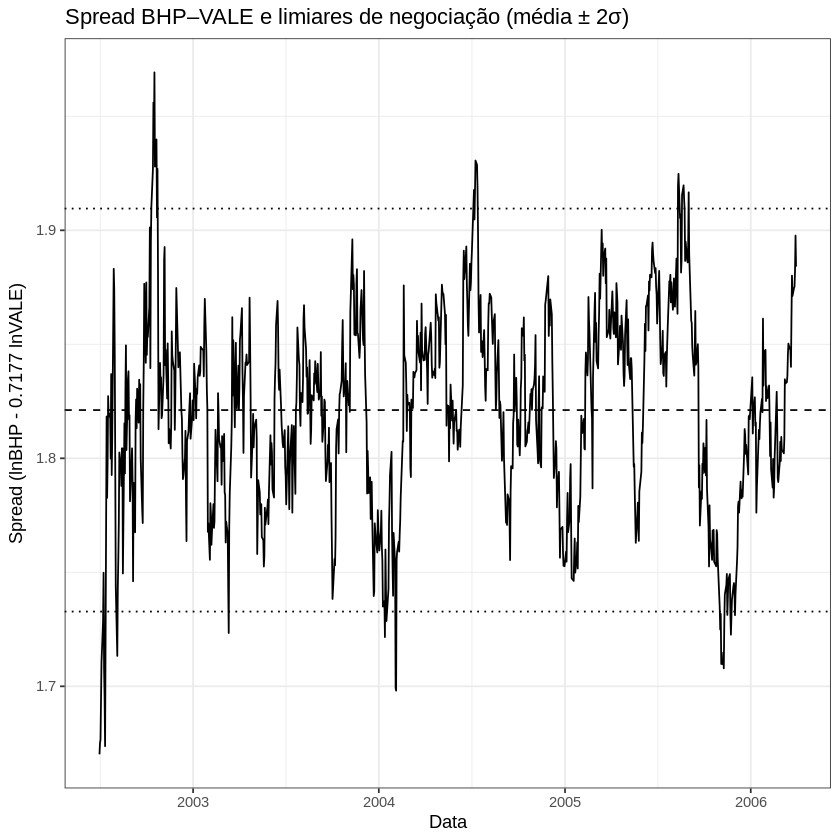

In [27]:
# Plotar o spread + limiares com ggplot2
ggplot(spread_tbl, aes(x = date, y = spread)) +
  geom_line() +
  geom_hline(yintercept = mu_spread, linetype = "dashed", size = 0.5) +
  geom_hline(yintercept = upper_band, linetype = "dotted", size = 0.5) +
  geom_hline(yintercept = lower_band, linetype = "dotted", size = 0.5) +
  labs(
    x = "Data",
    y = "Spread (lnBHP - 0.7177 lnVALE)",
    title = "Spread BHP–VALE e limiares de negociação (média ± 2σ)"
  )

#### Conclusão:

Para implementar a estratégia de Pairs Trading, calculamos a média e o desvio-padrão do spread obtido a partir do vetor de cointegração entre ln(BHP) e ln(VALE). O spread apresentou média de aproximadamente 1.82 e desvio-padrão de 0.044.

Com base nisso, definimos os limiares de negociação como média ± 2 desvios-padrão, resultando em:

Limiar superior (média + 2σ): 1.9095

Limiar inferior (média – 2σ): 1.7328

Esses limiares foram plotados junto ao spread, utilizando linhas horizontais no gráfico. Na prática, a estratégia funciona da seguinte forma:

Quando o spread ultrapassa o limiar superior, considera-se que o par está “esticado” para cima. O investidor venderia o ativo relativamente caro (BHP) e compraria o relativamente barato (VALE).

Quando o spread cai abaixo do limiar inferior, considera-se que o par está “esticado” para baixo. Nesse caso, compra-se BHP e vende-se VALE.

O fechamento das operações ocorre quando o spread retorna à média histórica, caracterizando a reversão à média, a base econométrica da estratégia.

Dessa forma, os limiares servem como regras operacionais objetivas para compras e vendas, permitindo implementar uma estratégia sistemática de Pairs Trading sustentada pela evidência de que o spread é estacionário e revertido à média.